# Crossover Resolution Under Lag-Context Learning Rules

The same crossover experiment as `transition_matrix.ipynb`, run over the learning rules of
*Context-Dependent Sequential Memory* instead of a catalogue of transition matrices $T$.

## The problem

Two sequences share a contiguous run of patterns. Cued from one branch's first pattern, the
trajectory reaches the shared run and then has to *choose*: the state there is identical
whichever branch brought it, so under the plain $\mu \rightarrow \mu+1$ chain the drive
toward the two continuations is symmetric and the branch is decided by noise and $\omega$
disorder rather than by history.

## What is different from `transition_matrix.ipynb`

That notebook's rule was a transition matrix,

$$\dot{\theta}_i = -\sin\theta_i \sum_{a}\sum_{\alpha} \xi_i^{a,\alpha}
  \sum_{\beta} T^a_{\alpha\beta}\,\bigl(m_i^{a,\beta}\bigr)^d,$$

and its closing note was that the gate $\sum_\beta T_{\alpha\beta}(m^\beta)^d$ is a **sum of
pure powers**: every overlap sits in its own term and no term multiplies two *different*
overlaps together. So a rule like "drive $\xi^{\mu+1}$ only when $m_\mu$ **and**
$m_{\mu-1}$ are both large" has no matrix, and the previous notebook says so explicitly and
does not attempt it.

That is exactly what the write-up's context rules are. Its fields are fourth-order of
bidegree $(2,1)$ — three overlap factors — and the context rules spend those factors at
**different lags**:

$$h^{\text{bigram}}_i = \sum_\mu \xi^{\mu+1}_i\, m_\mu |m_{\mu-1}|^2,
\qquad
h^{\text{coh3}}_i = \sum_\mu \xi^{\mu+1}_i\, m_\mu m_{\mu-1} m_{\mu-2}.$$

`kuramoto_context.py` is the one-term generalization that covers all of them:

$$\dot{\theta}_i = -\sin\theta_i \sum_{a}\sum_{\mu} \sum_{\text{terms}} w\;
  \xi_i^{a,\mu+s} \prod_{l \in \text{lags}} m_i^{a,\mu-l}$$

A rule is a **table of terms**, one row each: a target offset $s$, $d$ source lags, and a
weight. $d = 3$ and lags $(0,0,0)$ is $m_\mu^3$ — the existing dynamics. Everything the
write-up asks for is a different row.

## Disclaimer — every rule below is gain-normalized

**`kc.unit_gain` is not in the write-up.** The write-up carries a global coupling gain $g$
and does not say how to set it. This notebook sets it by a fixed rule, and every rule in
every table below has been through it. That choice is load-bearing rather than cosmetic, so
it belongs at the top rather than in a footnote.

- **Without it there is nothing to report.** A gate that reads a lag-$l$ overlap is
  multiplied, at its own operating point, by the residual overlap with a pattern $l$
  mutations back — about $(1-2\rho)^l$. So the coherent trigram runs at $0.22\times$ the
  forward rule's drive and scores **100% `incomplete` on both $P=5$ geometries**: it never
  traverses at all, which says nothing about whether the context it reads is useful. The
  cell under *The gain, measured* runs exactly that comparison.
- **What it does.** Divides each term by $(1-2\rho)^{\sum\text{lags}}$ and the rule by its
  total weight, so every rule has total gate $1$ when the state sits on the pattern it is
  driving from. It is the direct counterpart of `lag_matrix` normalizing a transition matrix
  to unit total weight in `transition_matrix.ipynb`.
- **What it cannot do.** It is a per-term constant. It rescales the drive uniformly; it
  cannot move a fixed point, and it cannot favour one branch over another at a crossing.
- **Where it is approximate.** It is calibrated at *one* operating point: $\rho$ =
  `CONFIG["corruption_rate"]`, at the idealized instant the state sits exactly on a stored
  pattern. Away from that instant the gates are not equal. Part III, where the corruption
  rate is drawn per trial, therefore re-sets the gain per trial from that trial's own rate.

Every number below is conditional on this normalization. Dropping `G` from the catalogue
reproduces the un-normalized behaviour.

### Note on implementation

Stored patterns are real ($\xi = \cos(\text{phase}) \in \{-1,+1\}$), so every overlap is
real and $|m|^2 = m^2$. The write-up's complex-overlap rules therefore collapse onto the
real forms in the table below, and the "coherent" rules differ from the magnitude-gated
ones by *sign sensitivity* rather than by phase.

A rule is **relative**, so unlike a transition matrix it does not have the end of the chain
baked in and the inherited `boundary` argument still means what it always did: `"self"`
(default) clamps both ends, `"cycle"` wraps both. Clamping at the *start* is what lets a cue
at pattern 0 launch the sequence at all — a lag-1 gate there has no earlier overlap to read,
and reading $m_0$ twice degrades the term to the plain forward rule.

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path


root_dir = Path.cwd().parent.parent
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import kuramoto.kuramoto_library as krm
import kuramoto.hetero_learning.kuramoto_hetero as kc

In [2]:
# Same configuration as transition_matrix.ipynb, so every row below is directly comparable
# to that notebook's numbers.
CONFIG = dict(
    dt=0.05,
    T=30.0,
    frequency_std=0.3,
    phase_noise=0.01,
    d=3,
    corruption_rate=0.2,
    tolerance=0.5,
    mode="ode",
)

N = 100
TRIALS = 20      # trials per rule; each runs 2 cueing attempts
MARGIN = 0.01
SEED_POOL = 10_000

# frequency_std must stay > 0: an exact, uncorrupted cue has theta in {0, pi}, so
# sin(theta_i) = 0 and the drive term vanishes identically -- with omega = 0 the
# trajectory is frozen at the cue and every rule scores "incomplete".
assert CONFIG["frequency_std"] > 0

## The rule catalogue

Section 2 of the write-up, minus the two rules that are not tables of relative indices (see
the note below). Every rule is $d = 3$, i.e. fourth order, so they all cost the same.

| name | eq | term $(s, \text{lags})$ | gate at pattern $\mu$ | what it says |
|---|---|---|---|---|
| `self` | (11) | $(0,(0,0,0))$ | $\xi^\mu m_\mu^3$ | Autoassociative stabilizer. No sequence at all; the control that should never traverse. |
| `forward` | (12) | $(1,(0,0,0))$ | $\xi^{\mu+1} m_\mu^3$ | Markov-1. The existing `xi_next` dynamics, reproduced exactly. **Baseline.** |
| `skip-two` | (13) | $(2,(0,0,0))$ | $\xi^{\mu+2} m_\mu^3$ | Still current-state-only: changes which pattern is driven, not what is read. |
| `self+forward` | (14) | mixture | — | Dwell plus advance. Tests whether inertia alone holds the branch. |
| `forward+skip2` | (14) | mixture | — | `transition_matrix.ipynb`'s `chain+skip`, as a rule. |
| `bigram` | (16) | $(1,(0,1,1))$ | $\xi^{\mu+1} m_\mu \lvert m_{\mu-1}\rvert^2$ | The simplest context rule: gated by how much overlap with the *previous* pattern survives. |
| `multilag` | (17) | $(1,(0,k,k))$ summed | $\xi^{\mu+1} m_\mu \sum_k w_k \lvert m_{\mu-k}\rvert^2$ | Several recent overlaps gate the transition at once. |
| `coh bigram` | (18) | $(1,(0,0,1))$ | $\xi^{\mu+1} m_\mu^2 m_{\mu-1}$ | One factor moved from the gate to the drive: the lagged overlap enters linearly, so its *sign* matters. |
| `coh trigram` | (19) | $(1,(0,1,2))$ | $\xi^{\mu+1} m_\mu m_{\mu-1} m_{\mu-2}$ | Two-step context inside the same fourth-order budget. The write-up's headline rule. |



### The gain

`transition_matrix.ipynb` normalized every matrix to unit total weight so that adding terms
did not change the overall drive. The same control is needed here and it is not optional.

A rule that reads only $m_\mu$ has a gate of $\approx 1$ whenever the state sits on pattern
$\mu$. One that also reads $m_{\mu-l}$ is multiplied there by the residual overlap with a
pattern $l$ mutations back, which for a corruption chain at rate $\rho$ is about
$(1-2\rho)^l$ — at $\rho = 0.2$ that is $0.6$ per lag. So the coherent trigram's gate runs
at $0.6 \cdot 0.36 \approx 0.22$ of the forward rule's and, un-normalized, simply does not
traverse: **every context rule scores 100% incomplete**, which says nothing about whether
the context it reads is useful.

`kc.unit_gain(rule, rho)` divides each term by $(1-2\rho)^{\sum \text{lags}}$ and the rule by
its total weight, so every rule below has total gate $1$ at its own operating point. This is
the write-up's global coupling gain $g$, set so the comparison is about *information* and not
about drive strength.

In [3]:
RAW_CATALOGUE = {
    "self":          kc.self_rule(),
    "forward":       kc.forward_rule(),
    "skip-two":      kc.skip_rule(nhop=2),
    "self+forward":  kc.mixture(kc.self_rule(weight=0.3), kc.forward_rule(weight=1.0)),
    "forward+skip2": kc.mixture(kc.forward_rule(weight=1.0), kc.skip_rule(2, weight=0.5)),
    "bigram":        kc.bigram_rule(),
    "multilag":      kc.multilag_rule((1.0, 1.0, 1.0)),
    "coh bigram":    kc.coherent_bigram_rule(),
    "coh trigram":   kc.coherent_trigram_rule(),
}

# The gain step, applied once here at the configured rate. Part III re-applies it per trial,
# which is why the raw table is kept alongside the normalized one.
G = lambda rule: kc.unit_gain(rule, CONFIG["corruption_rate"])
CATALOGUE = {name: G(rule) for name, rule in RAW_CATALOGUE.items()}

print(f"{'rule':<15}{'target s':>9}{'lags':>12}{'weight':>10}")
print("-" * 46)
for name, rule in CATALOGUE.items():
    for r, row in enumerate(rule):
        lags = ",".join(f"{int(l)}" for l in row[1:-1])
        print(f"{name if r == 0 else '':<15}{int(row[0]):>9}{'(' + lags + ')':>12}{row[-1]:>10.3f}")

rule            target s        lags    weight
----------------------------------------------
self                   0     (0,0,0)     1.000
forward                1     (0,0,0)     1.000
skip-two               2     (0,0,0)     1.000
self+forward           0     (0,0,0)     0.231
                       1     (0,0,0)     0.769
forward+skip2          1     (0,0,0)     0.667
                       2     (0,0,0)     0.333
bigram                 1     (0,1,1)     2.778
multilag               1     (0,0,0)     0.333
                       1     (0,1,1)     0.926
                       1     (0,2,2)     2.572
coh bigram             1     (0,0,1)     1.667
coh trigram            1     (0,1,2)     4.630


### Reading a rule table

Each row is one term: `target s` is which pattern it drives relative to $\mu$, `lags` are
which patterns it reads (counting *backwards*, so 0 is $\mu$ itself), and `weight` is its
coefficient. `forward` is the single row $(1, (0,0,0))$ — drive $\xi^{\mu+1}$, read
$m_\mu$ three times.

The weights are what `unit_gain` did. `coh trigram` carries $4.63 = 1/0.6^3$ because its
gate reads two lagged overlaps; `multilag`'s three terms carry $0.33, 0.93, 2.57$, which are
equal *contributions* of $1/3$ each once the operating-point gate is accounted for.

## Validation: `forward` must reproduce the baseline exactly

`forward_rule()` is the `xi_next` successor chain written as a rule, so `ContextNetwork`
under it and the stock `KuramotoNetwork` should integrate the same trajectory. Any
difference here means the extension changed the dynamics rather than generalizing them.

This is the same check `transition_matrix.ipynb` runs on `shift_transition(P)`, which came
back at $4.4 \times 10^{-15}$.

In [4]:
check_multi = krm.generate_multi_sequence(N=N, seq_len=4, corruption_rate=CONFIG["corruption_rate"],
                                          count=2, seed=7)

base_net = krm.KuramotoNetwork(N=N, seed=10, **CONFIG)
fwd_net  = kc.ContextNetwork(rule=kc.forward_rule(), N=N, seed=10, **CONFIG)

ref = base_net.simulate(check_multi, cue=check_multi["A"], cue_idx=0)
new = fwd_net.simulate(check_multi, cue=check_multi["A"], cue_idx=0)

print("history shapes:", ref["theta_history"].shape, new["theta_history"].shape)
print("max |dtheta|  :", np.abs(ref["theta_history"] - new["theta_history"]).max())

history shapes: (601, 100) (601, 100)
max |dtheta|  : 2.886579864025407e-15


## Build one crossover trial

`make_crossover_multisequence3` and `classify_unshared` are `transition_matrix.ipynb`'s,
unchanged: two sequences of `seq_len` patterns sharing a contiguous run at `shared_idx`,
built as a mutation chain so consecutive patterns overlap at about 0.6, with both branches
holding the same array object across the run so those overlaps are bit-identical.

Scoring is that notebook's too — every **unshared** pattern of the cued sequence must come
back, in order. Shared positions carry no information (both sequences store the same array,
so `argmax` always awards the label to whichever was added first) and are skipped.

In [5]:
def make_crossover_multisequence3(N, corruption_rate, origin_seed, mutation_seeds,
                                  seq_len, shared_idx):
    """Two sequences of `seq_len` patterns sharing a contiguous run at `shared_idx`.

    Built as a mutation chain rather than a star around one origin, so consecutive patterns
    stay close enough for the dynamics to traverse. Both branches hold the same array object
    across the run, so those overlaps are bit-identical and the ambiguity is exact."""
    shared_idx = sorted(shared_idx)
    lo, hi = shared_idx[0], shared_idx[-1]
    if shared_idx != list(range(lo, hi + 1)):
        raise ValueError("shared_idx must be a contiguous run.")
    if not (0 < lo and hi < seq_len - 1):
        raise ValueError("The run needs at least one unshared pattern on each side.")

    seeds = iter(mutation_seeds)
    mutate = lambda v: krm.corrupt_phase(v, corruption_rate, np.random.default_rng(next(seeds)))

    run = [np.random.default_rng(origin_seed).choice([0.0, np.pi], size=N)]
    for _ in range(hi - lo):
        run.append(mutate(run[-1]))

    multi = krm.MultiSequence()
    for name in ("A", "B"):
        prefix, v = [], run[0]
        for _ in range(lo):                            # backwards off the front
            v = mutate(v); prefix.append(v)
        prefix.reverse()
        suffix, v = [], run[-1]
        for _ in range(seq_len - 1 - hi):              # forwards off the back
            v = mutate(v); suffix.append(v)
        multi.add(krm.sequence_from_patterns(name, prefix + list(run) + suffix))
    return multi


def classify_unshared(retrieved, multi, name, shared_idx):
    """Outcome of one cueing attempt: every unshared pattern of the cued sequence must come
    back, in order.

    correct    = all unshared positions decoded, in order, on the cued branch
    crossed    = the other branch showed up at an unshared position first
    incomplete = the path ran out before all of them appeared"""
    other = "B" if name == "A" else "A"
    shared = set(shared_idx)
    pending = iter([k for k in range(len(multi[name])) if k not in shared])
    target = next(pending, None)

    for seq, idx in retrieved:
        if target is None:
            break
        if idx in shared:
            continue
        if seq == other and idx >= target:
            return "crossed"
        if seq == name and idx == target:
            target = next(pending, None)
    return "correct" if target is None else "incomplete"

### The branch-choice diagnostic

The write-up asks for one more measurement than the three-way outcome: *"a branch-choice
diagnostic at the shared state, comparing correct and wrong successor drive"*.

For a shared run ending at index $h$, the two candidate continuations are
$(\text{cued},\,h{+}1)$ and $(\text{other},\,h{+}1)$. `branch_correct` records whether the
cued branch's continuation reached the higher peak overlap, and `margin` by how much. This
is scored on **every** attempt including those the decoder calls `incomplete`, so it
separates *"picked the wrong branch"* from *"picked the right branch but never locked onto
it hard enough to clear `tolerance`"* — two failures the three-way outcome lumps together.

In [6]:
def run_crossover_trial(net, rng, seq_len, shared_idx, duration):
    """One crossover instance, cued once from each sequence's first pattern."""
    origin_seed = int(rng.integers(SEED_POOL))
    mutation_seeds = rng.choice(SEED_POOL, size=12, replace=False).tolist()
    multi = make_crossover_multisequence3(N, CONFIG["corruption_rate"], origin_seed,
                                          mutation_seeds, seq_len, shared_idx)
    labels = multi.labels()
    hi = max(shared_idx)

    out = {}
    for name in ("A", "B"):
        other = "B" if name == "A" else "A"
        result = net.simulate(multi, cue=multi[name], cue_idx=0, T=duration)
        retrieved = net.decode_sequence_online(result, multi, margin=MARGIN)

        overlaps = net.overlaps(result["theta_history"], multi)
        own_peak   = overlaps[:, labels.index((name, hi + 1))].max()
        other_peak = overlaps[:, labels.index((other, hi + 1))].max()

        out[name] = dict(result=result, retrieved=retrieved,
                         outcome=classify_unshared(retrieved, multi, name, shared_idx),
                         branch_correct=bool(own_peak > other_peak),
                         margin=float(own_peak - other_peak))
    return multi, out


def rule_sweep(catalogue, seq_len, shared_idx, duration, trials=TRIALS, seed=0, verbose=True):
    """The sweep over whatever catalogue it is handed. Every rule gets a freshly seeded
    `default_rng(seed)`, so all of them see the same crossover instances."""
    stats, first = {}, {}
    for rule, table in catalogue.items():
        net = kc.ContextNetwork(rule=table, N=N, seed=10, **CONFIG)
        rng = np.random.default_rng(seed)
        counter, wins, margins = Counter(), 0, []
        for trial in range(trials):
            multi, out = run_crossover_trial(net, rng, seq_len, shared_idx, duration)
            if trial == 0:
                first[rule] = (net, multi, out)
            for name in ("A", "B"):
                counter[out[name]["outcome"]] += 1
                wins += out[name]["branch_correct"]
                margins.append(out[name]["margin"])
        attempts = sum(counter.values())
        stats[rule] = dict(counter=counter, attempts=attempts,
                           branch_correct=wins / attempts, margin=float(np.mean(margins)))
        if verbose:
            print(f"{rule:<15} correct={counter['correct'] / attempts:>5.0%}  "
                  f"crossed={counter['crossed'] / attempts:>5.0%}  "
                  f"incomplete={counter['incomplete'] / attempts:>5.0%}   "
                  f"branch-correct={wins / attempts:>5.0%}  margin={np.mean(margins):>+6.3f}")
    return stats, first


kinds = ["correct", "crossed", "incomplete"]


def plot_rule_stats(stats, title, axes=None):
    """Left: the stacked outcome bar, as in transition_matrix.ipynb. Right: the
    branch-choice diagnostic, which the outcome bar cannot show."""
    names = list(stats)
    attempts = stats[names[0]]["attempts"]
    if axes is None:
        _, axes = plt.subplots(1, 2, figsize=(15, 4.4))

    bottom = np.zeros(len(names))
    for kind in kinds:
        heights = np.array([stats[n]["counter"][kind] / attempts for n in names])
        axes[0].bar(names, heights, bottom=bottom, label=kind)
        bottom += heights
    axes[0].axhline(0.5, color="k", ls="--", lw=1, label="chance")
    axes[0].set_ylabel("fraction of cueing attempts")
    axes[0].set_title(f"{title} -- retrieval outcome  ({attempts} attempts per rule)")
    axes[0].legend(fontsize=8)

    axes[1].bar(names, [stats[n]["branch_correct"] for n in names], color="tab:purple")
    axes[1].axhline(0.5, color="k", ls="--", lw=1, label="chance")
    axes[1].set_ylabel("fraction branch-correct")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title(f"{title} -- branch choice at the shared state")
    axes[1].legend(fontsize=8)

    for ax in axes:
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
        ax.grid(True, axis="y", alpha=0.3)
    return axes

## The three geometries

The same three as `transition_matrix.ipynb`, so the rows are comparable to that notebook's.
For a shared run at indices $\ell \ldots h$ of length $L$, the branch is decided while
driving pattern $h+1$, i.e. at $\mu = h$. A term reading lag $l$ then reads pattern $h - l$,
which is unshared only when $h - l < \ell$, so

$$\boxed{\;\text{reach} \;\ge\; L\;}$$

is what a rule needs to see anything that distinguishes the branches at all. The transition
matrix needed $\texttt{nhop} \ge L+1$ for the same reason; here the requirement lands on how
far *back the gate reads* instead of how far *forward the drive jumps*.

| experiment | $P$ | shared indices | $L$ | reach needed |
|---|---|---|---|---|
| 1 | 3 | $\{1\}$ | 1 | 1 — `bigram`, `coh bigram` |
| 2 | 5 | $\{2\}$ | 1 | 1 — `bigram`, `coh bigram` |
| 3 | 5 | $\{1,2,3\}$ | 3 | 3 — nothing in the catalogue reaches that far |

`coh trigram`, at reach 2, is over-provisioned for experiments 1-2 and still short for 3.

### The gain, measured

Finding 2 is a claim about the notebook itself, so it is worth running: the same two rules
with and without `unit_gain`, on the $P=5$ run-of-three geometry. (At $P=3$ the difference is
milder, because `boundary="self"` clamps the lags of most terms back onto $m_\mu$ and the raw
rules partly degenerate into the forward rule, which is well normalized by construction.)

In [7]:
GAIN_CHECK = {
    "bigram (raw)":      kc.bigram_rule(),
    "bigram":            G(kc.bigram_rule()),
    "coh trigram (raw)": kc.coherent_trigram_rule(),
    "coh trigram":       G(kc.coherent_trigram_rule()),
}

print("P = 5, shared {1, 2, 3}")
_ = rule_sweep(GAIN_CHECK, 5, (1, 2, 3), duration=100.0, trials=8)

P = 5, shared {1, 2, 3}
bigram (raw)    correct=  44%  crossed=  56%  incomplete=   0%   branch-correct=  69%  margin=+0.006
bigram          correct=  50%  crossed=  38%  incomplete=  12%   branch-correct=  56%  margin=+0.035
coh trigram (raw) correct=  50%  crossed=  38%  incomplete=  12%   branch-correct=  56%  margin=+0.004
coh trigram     correct=  50%  crossed=  38%  incomplete=  12%   branch-correct=  56%  margin=+0.035


## Experiment 1 — $P=3$, one crossover

P = 3, shared {1}
self            correct=   0%  crossed=   0%  incomplete= 100%   branch-correct=  45%  margin=+0.005
forward         correct=  52%  crossed=  48%  incomplete=   0%   branch-correct=  52%  margin=+0.019
skip-two        correct= 100%  crossed=   0%  incomplete=   0%   branch-correct= 100%  margin=+0.465
self+forward    correct=  15%  crossed=  15%  incomplete=  70%   branch-correct=  42%  margin=+0.001
forward+skip2   correct=  70%  crossed=  30%  incomplete=   0%   branch-correct=  70%  margin=+0.166
bigram          correct=  18%  crossed=  10%  incomplete=  72%   branch-correct=  85%  margin=+0.058
multilag        correct=  18%  crossed=   0%  incomplete=  82%   branch-correct=  98%  margin=+0.084
coh bigram      correct=  45%  crossed=  35%  incomplete=  20%   branch-correct=  62%  margin=+0.055
coh trigram     correct=  15%  crossed=   0%  incomplete=  85%   branch-correct=  98%  margin=+0.085


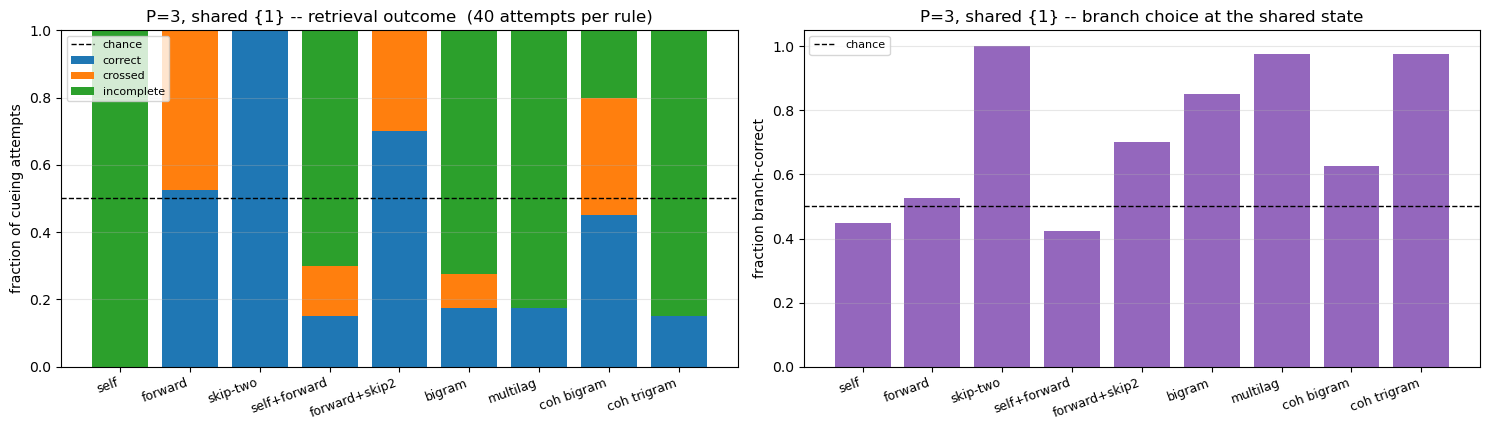

In [8]:
print("P = 3, shared {1}")
stats_e1, first_e1 = rule_sweep(CATALOGUE, 3, (1,), duration=60.0)
plot_rule_stats(stats_e1, "P=3, shared {1}")
plt.tight_layout(); plt.show()

### Note on `skip-two`

`skip-two` scores 100% on both panels, and it is the same artefact
`transition_matrix.ipynb` documents for its `skip nhop=2` matrix: at $P=3$ the rule drives
$\mu \rightarrow \mu+2$, so cued at $A[0]$ it targets $A[2]$ directly and the shared centre
is never a target of the drive at all. It does not resolve the crossover; it sidesteps it.
The middle label still shows up in the decoded path because the centre sits *between* $A[0]$
and $A[2]$ in overlap space and the trajectory passes through a region of high centre-overlap
on the way. A decoded label is not a driven pattern. At $P=5$, where a skip of two is no
longer the whole sequence, it drops back to the pack.

## Experiment 2 — $P=5$, one crossover at index 2

P = 5, shared {2}
self            correct=   0%  crossed=   0%  incomplete= 100%   branch-correct=  57%  margin=+0.004
forward         correct=  50%  crossed=  48%  incomplete=   2%   branch-correct=  55%  margin=+0.000
skip-two        correct=   2%  crossed=  30%  incomplete=  68%   branch-correct=  80%  margin=+0.087
self+forward    correct=  30%  crossed=  35%  incomplete=  35%   branch-correct=  50%  margin=-0.002
forward+skip2   correct=  35%  crossed=  38%  incomplete=  28%   branch-correct=  68%  margin=+0.051
bigram          correct=  52%  crossed=  28%  incomplete=  20%   branch-correct=  72%  margin=+0.105
multilag        correct=  52%  crossed=  25%  incomplete=  22%   branch-correct=  78%  margin=+0.119
coh bigram      correct=  50%  crossed=  35%  incomplete=  15%   branch-correct=  70%  margin=+0.071
coh trigram     correct=  57%  crossed=  20%  incomplete=  22%   branch-correct=  80%  margin=+0.135


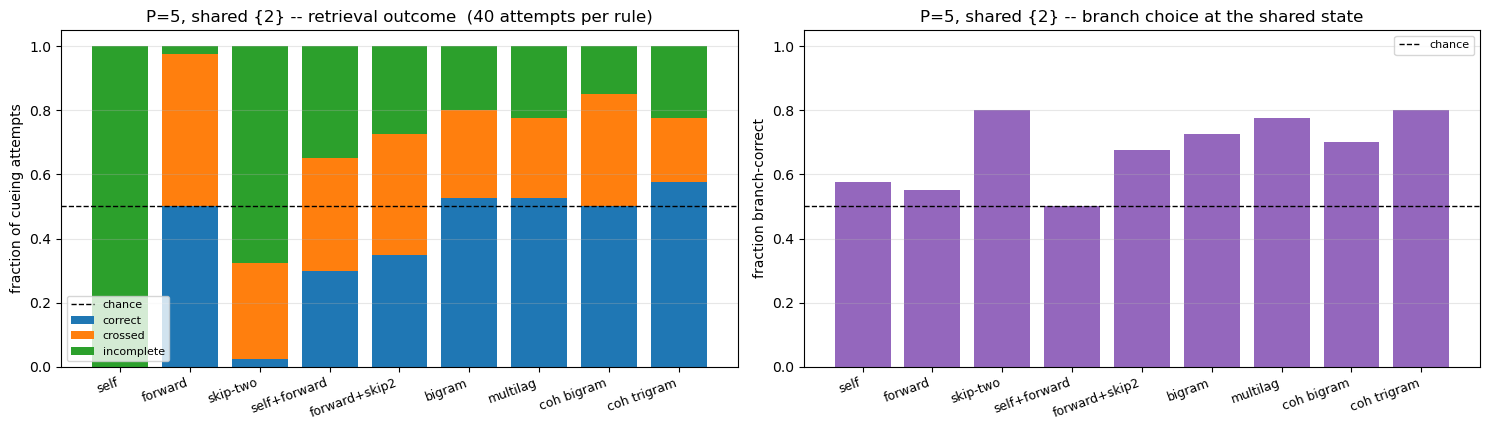

In [9]:
print("P = 5, shared {2}")
stats_e2, first_e2 = rule_sweep(CATALOGUE, 5, (2,), duration=100.0)
plot_rule_stats(stats_e2, "P=5, shared {2}")
plt.tight_layout(); plt.show()

## Experiment 3 — $P=5$, shared run of 3

P = 5, shared {1, 2, 3}
self            correct=   0%  crossed=   0%  incomplete= 100%   branch-correct=  52%  margin=-0.004
forward         correct=  52%  crossed=  38%  incomplete=  10%   branch-correct=  55%  margin=+0.047
skip-two        correct=  57%  crossed=  42%  incomplete=   0%   branch-correct=  57%  margin=+0.050
self+forward    correct=  12%  crossed=  12%  incomplete=  75%   branch-correct=  52%  margin=+0.000
forward+skip2   correct=  52%  crossed=  48%  incomplete=   0%   branch-correct=  52%  margin=+0.016
bigram          correct=  48%  crossed=  32%  incomplete=  20%   branch-correct=  57%  margin=+0.046
multilag        correct=  35%  crossed=  30%  incomplete=  35%   branch-correct=  52%  margin=+0.015
coh bigram      correct=  57%  crossed=  38%  incomplete=   5%   branch-correct=  60%  margin=+0.062
coh trigram     correct=  38%  crossed=  30%  incomplete=  32%   branch-correct=  52%  margin=+0.015


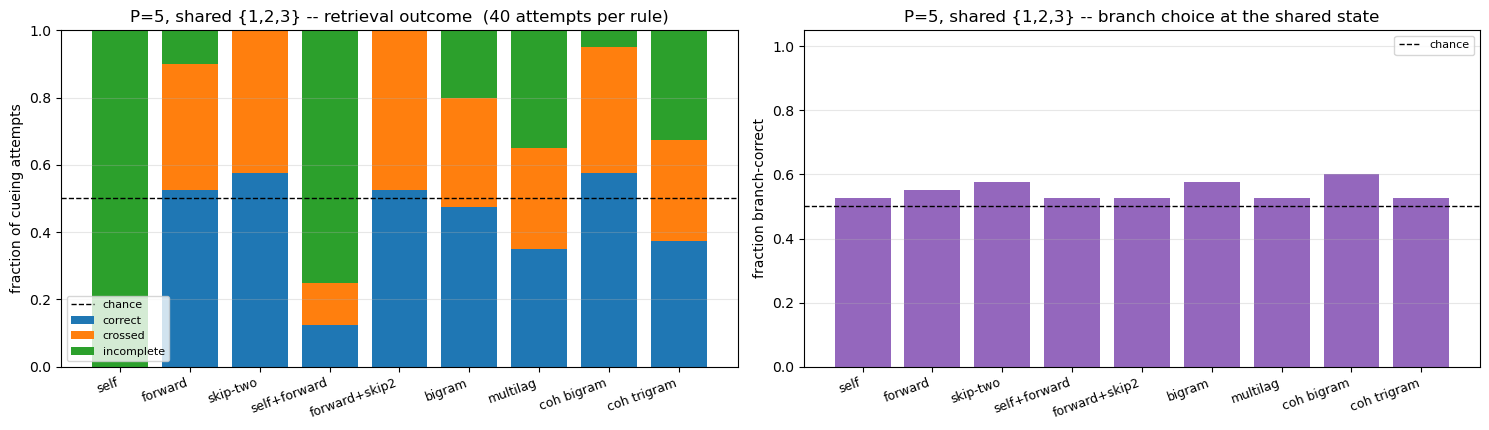

In [10]:
print("P = 5, shared {1, 2, 3}")
stats_e3, first_e3 = rule_sweep(CATALOGUE, 5, (1, 2, 3), duration=100.0)
plot_rule_stats(stats_e3, "P=5, shared {1,2,3}")
plt.tight_layout(); plt.show()

### Reading the two panels together

The outcome bar and the branch-choice bar say different things, and on experiment 1 they say
*opposite* things. `forward` is at chance on branch choice and scores well on `correct`;
`bigram`, `multilag` and `coh trigram` are far above chance on branch choice and score badly
on `correct`, with the difference sitting in `incomplete`.

That is not a contradiction. It splits the crossover problem into two halves:

1. **Picking the branch.** Every context rule does this, and the current-state-only rules do
   not. The gate at the shared state is $m_\star \lvert m_{\mu-1}\rvert^2$, and $m_{\mu-1}$
   is larger for the branch the trajectory actually came from. This is the write-up's
   mechanism and it works.
2. **Committing to it.** Reaching a pattern with overlap above `tolerance = 0.8` needs the
   driven pattern's *own* overlap to amplify itself — the winner-take-all that makes the
   trajectory lock rather than settle in a mixture. The forward rule's gate is $m_\mu^3$, so
   its terminal self-term is cubic in the pattern it is driving. A context rule spends
   factors on *lagged* overlaps and has only $m_\mu^1$ or $m_\mu^2$ left, so its
   self-amplification is weaker and the state settles between the two continuations instead
   of on one.

`coh bigram` is the one rule that does both, and it is the only context rule that keeps two
factors on the current overlap ($m_\mu^2 m_{\mu-1}$) -- the only one whose `incomplete`
fraction stays near the forward rule's on all three geometries.

**On sample size.** Every rule gets 40 attempts, so a fraction here carries a standard error
of about 8 percentage points and differences under ~15 points are not resolved. What survives
that are the large effects: `forward` at chance versus the context rules at 85-98% on branch
choice at $P=3$, the matching collapse of those same rules into `incomplete`, and the whole
catalogue sitting at chance on the shared run of three.

---

## Knob 1 — the reach

The catalogue fixes each rule's lags. Both context families generalize to an arbitrary
reach $r$ with the same number of factors:

$$\texttt{bigram\_rule(lag=}r\texttt{)}: \;\; \xi^{\mu+1} m_\mu \lvert m_{\mu-r}\rvert^2
\qquad
\texttt{coherent\_trigram\_rule(lag=}r\texttt{)}: \;\; \xi^{\mu+1} m_\mu m_{\mu-r+1} m_{\mu-r}$$

At $r=1$ the coherent family degenerates to `coh bigram`, and at $r=2$ it is the write-up's
eq (19). The prediction from the box above is a threshold at $r = L$. On `shared {2}` that is
$r \ge 1$, i.e. *every* reach tested qualifies and the curve should simply sit above chance
throughout; the informative panel is `shared {1,2,3}`, where only $r \ge 3$ can read an
unshared pattern at all and everything below it is blind by construction.

P = 5, shared {2}   branch information first available at reach = 1
bigram r=1      correct=  52%  crossed=  28%  incomplete=  20%   branch-correct=  72%  margin=+0.105
bigram r=2      correct=  42%  crossed=  28%  incomplete=  30%   branch-correct=  80%  margin=+0.130
bigram r=3      correct=  42%  crossed=  25%  incomplete=  32%   branch-correct=  75%  margin=+0.135
bigram r=4      correct=  18%  crossed=  28%  incomplete=  55%   branch-correct=  62%  margin=+0.059
coh r=1         correct=  50%  crossed=  35%  incomplete=  15%   branch-correct=  70%  margin=+0.071
coh r=2         correct=  57%  crossed=  20%  incomplete=  22%   branch-correct=  80%  margin=+0.135
coh r=3         correct=  40%  crossed=  30%  incomplete=  30%   branch-correct=  72%  margin=+0.123
coh r=4         correct=  28%  crossed=  30%  incomplete=  42%   branch-correct=  68%  margin=+0.097

P = 5, shared {1,2,3}   branch information first available at reach = 3
bigram r=1      correct=  48%  crossed=  32%  incom

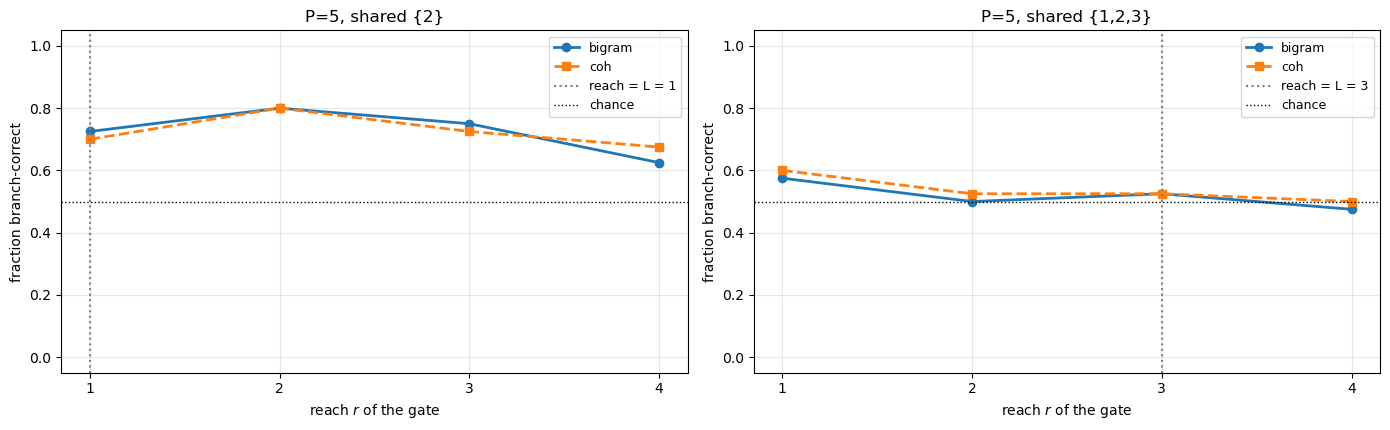

In [11]:
REACH = [1, 2, 3, 4]

reach_stats = {}
for tag, shared in [("shared {2}", (2,)), ("shared {1,2,3}", (1, 2, 3))]:
    need = max(shared) - min(shared) + 1
    print(f"P = 5, {tag}   branch information first available at reach = {need}")
    catalogue = {f"bigram r={r}": G(kc.bigram_rule(lag=r)) for r in REACH}
    catalogue.update({f"coh r={r}": G(kc.coherent_trigram_rule(lag=r)) for r in REACH})
    reach_stats[tag] = rule_sweep(catalogue, 5, shared, 100.0)[0]
    print()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, (tag, stats) in zip(axes, reach_stats.items()):
    need = 1 if tag == "shared {2}" else 3
    for prefix, style in [("bigram", "-o"), ("coh", "--s")]:
        ax.plot(REACH, [stats[f"{prefix} r={r}"]["branch_correct"] for r in REACH],
                style, lw=2, label=f"{prefix}")
    ax.axvline(need, color="tab:grey", ls=":", lw=1.5, label=f"reach = L = {need}")
    ax.axhline(0.5, color="k", ls=":", lw=1, label="chance")
    ax.set_xlabel("reach $r$ of the gate"); ax.set_xticks(REACH)
    ax.set_ylabel("fraction branch-correct"); ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"P=5, {tag}"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Why reach alone does not rescue experiment 3

Reach $\ge L$ is necessary and it is not sufficient. `coh r=3` on `shared {1,2,3}` *does*
read $m_{a_0}$, the only overlap that can distinguish the branches, and it is still at chance.

The reason is that the quantity it reads has already decayed by the time it is read. What the
gate compares is $m_{a_{\ell-1}}$ against $m_{b_{\ell-1}}$ — the traversed against the
untraversed predecessor of the shared run. Both are the *same distance* from the shared
patterns in mutation steps, so their static overlaps are identical and the entire signal is
the dynamic residual of having actually passed through one of them. The cell below measures
that residual: it runs the baseline `forward` trajectory, cued from $A[0]$, and reads the gap
at the moment the state peaks on each pattern in turn.

P=5, shared {2}  (L=1)   mean gap  m(A[1]) - m(B[1])  at the peak of each pattern
     A[0]   +0.412   A[1]   +0.405   A[2]*   +0.084   A[3]^   +0.015   A[4]   -0.021   
     * = shared,  ^ = the branch point, where the gate still has to be reading it

P=5, shared {1,2,3}  (L=3)   mean gap  m(A[0]) - m(B[0])  at the peak of each pattern
     A[0]   +0.632   A[1]*   +0.211   A[2]*   +0.021   A[3]*   -0.010   A[4]^   +0.023   
     * = shared,  ^ = the branch point, where the gate still has to be reading it



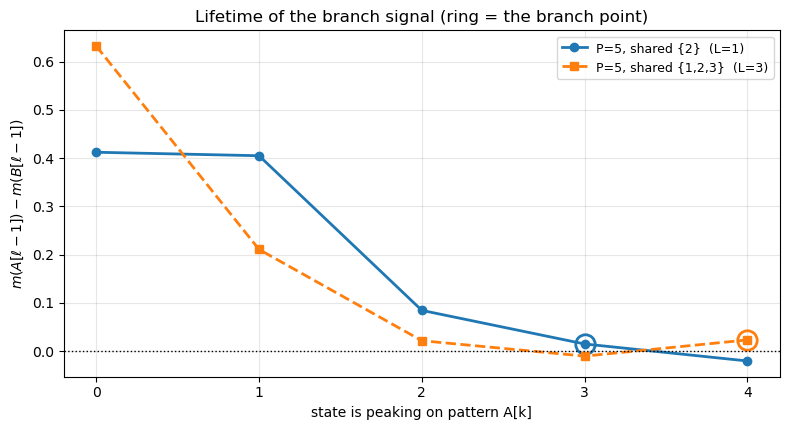

In [12]:
GAP_TRIALS = 10

fwd = kc.ContextNetwork(rule=G(kc.forward_rule()), N=N, seed=10, **CONFIG)
fig, ax = plt.subplots(figsize=(8, 4.4))

for tag, shared, style in [("shared {2}  (L=1)", (2,), "-o"),
                           ("shared {1,2,3}  (L=3)", (1, 2, 3), "--s")]:
    lo, hi = min(shared), max(shared)
    gaps = np.zeros((GAP_TRIALS, 5))
    for trial in range(GAP_TRIALS):
        rng = np.random.default_rng(trial)
        multi = make_crossover_multisequence3(
            N, CONFIG["corruption_rate"], int(rng.integers(SEED_POOL)),
            rng.choice(SEED_POOL, size=12, replace=False).tolist(), 5, shared)
        labels = multi.labels()
        result = fwd.simulate(multi, cue=multi["A"], cue_idx=0, T=100.0)
        ov = fwd.overlaps(result["theta_history"], multi)
        gap = ov[:, labels.index(("A", lo - 1))] - ov[:, labels.index(("B", lo - 1))]
        for k in range(5):
            gaps[trial, k] = gap[int(np.argmax(ov[:, labels.index(("A", k))]))]

    print(f"P=5, {tag}   mean gap  m(A[{lo-1}]) - m(B[{lo-1}])  at the peak of each pattern")
    print("     " + "".join(f"A[{k}]{'*' if k in shared else ''}{'^' if k == hi+1 else ''}"
                            f"{gaps[:, k].mean():>+9.3f}   " for k in range(5)))
    print("     * = shared,  ^ = the branch point, where the gate still has to be reading it\n")

    line, = ax.plot(range(5), gaps.mean(0), style, lw=2, label=f"P=5, {tag}")
    ax.plot(hi + 1, gaps[:, hi + 1].mean(), "o", ms=14, mfc="none", mew=2, color=line.get_color())

ax.axhline(0.0, color="k", ls=":", lw=1)
ax.set_xlabel("state is peaking on pattern A[k]"); ax.set_xticks(range(5))
ax.set_ylabel(r"$m(A[\ell-1]) - m(B[\ell-1])$")
ax.set_title("Lifetime of the branch signal (ring = the branch point)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

## Knob 2 — the multilag weights

`multilag` is the one rule in the catalogue with weights to sweep, eq (17):

$$h^{\text{multilag}}_i = \sum_\mu \xi^{\mu+1}_i m_\mu
  \bigl(w_0 \lvert m_\mu\rvert^2 + w_1 \lvert m_{\mu-1}\rvert^2 + w_2 \lvert m_{\mu-2}\rvert^2\bigr)$$

$w_0$ is the ungated forward term and $w_1, w_2$ are the context gates, so
$(1,0,0)$ is `forward` and $(0,1,0)$ is `bigram`. After `unit_gain` the weights are
*shares*: they say how much each lag contributes at the operating point, and they sum to 1.

This is the trade-off the two panels above set up — $w_0$ buys commitment, $w_1$ and $w_2$
buy branch information — so the grid should show them pulling against each other.

P=3 shared {1}   (correct / branch-correct)      w2=0         w2=0.5       w2=1         w2=2         
  w1=0                                  50% /  50%    20% /  90%    17% /  97%    17% /  97%
  w1=0.5                                40% /  57%    20% /  87%    17% /  97%    17% /  97%
  w1=1                                  40% /  60%    17% /  87%    20% /  97%    17% /  97%
  w1=2                                  37% /  63%    20% /  83%    17% /  93%    17% /  97%

P=5 shared {1,2,3}   (correct / branch-correct)      w2=0         w2=0.5       w2=1         w2=2         
  w1=0                                  53% /  57%    37% /  50%    40% /  53%    40% /  53%
  w1=0.5                                50% /  53%    47% /  63%    37% /  53%    37% /  53%
  w1=1                                  53% /  57%    47% /  63%    37% /  53%    37% /  53%
  w1=2                                  60% /  63%    53% /  63%    47% /  60%    37% /  53%



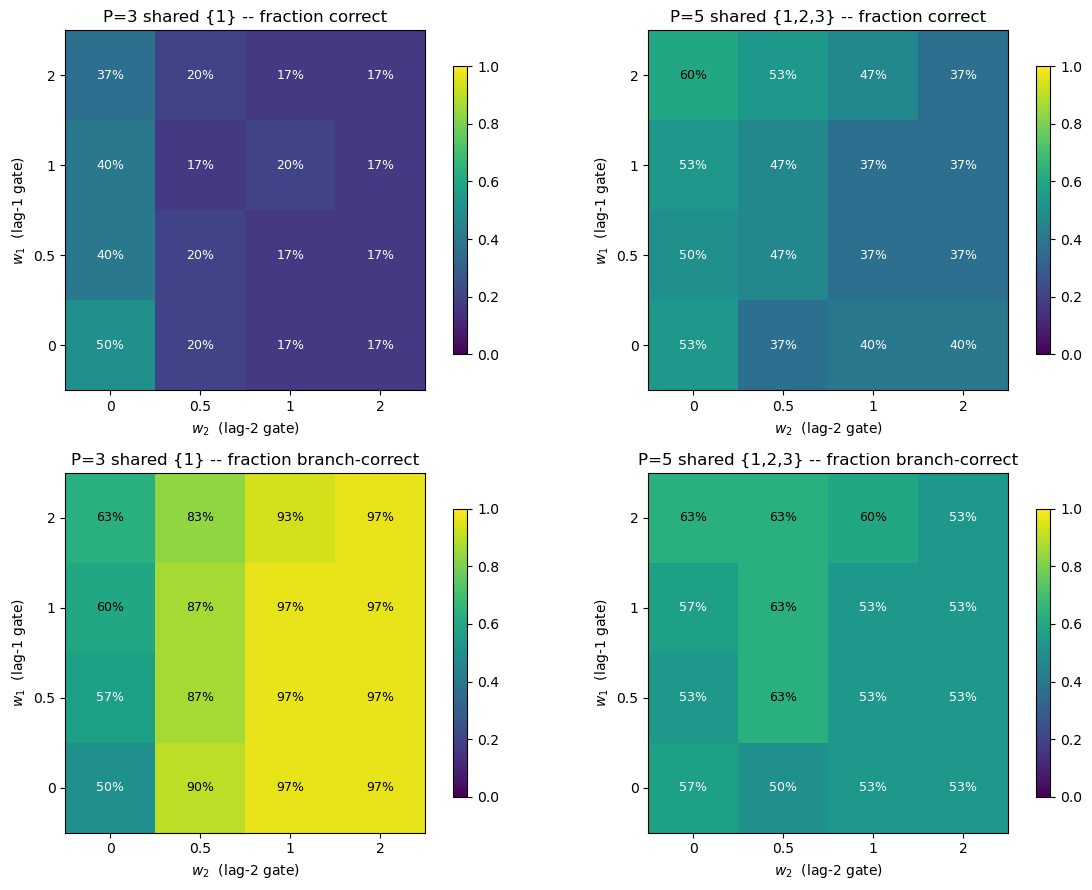

In [13]:
GRID_W = [0.0, 0.5, 1.0, 2.0]     # weight on the lag-1 and lag-2 gates, with w0 = 1

grid_stats = {}
for tag, shared, seq_len, dur in [("P=3 shared {1}", (1,), 3, 60.0),
                                  ("P=5 shared {1,2,3}", (1, 2, 3), 5, 100.0)]:
    catalogue = {(w1, w2): G(kc.multilag_rule((1.0, w1, w2)))
                 for w1 in GRID_W for w2 in GRID_W}
    grid_stats[tag] = rule_sweep(catalogue, seq_len, shared, dur, trials=15, verbose=False)[0]
    print(f"{tag}   (correct / branch-correct)      " + "".join(f"w2={w2:<10g}" for w2 in GRID_W))
    for w1 in GRID_W:
        row = ""
        for w2 in GRID_W:
            s = grid_stats[tag][(w1, w2)]
            row += f"{s['counter']['correct'] / s['attempts']:>7.0%} /{s['branch_correct']:>5.0%}"
        print(f"  w1={w1:<5g}                          {row}")
    print()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for col, (tag, stats) in enumerate(grid_stats.items()):
    for row, (key, label) in enumerate([("correct", "fraction correct"),
                                        ("branch", "fraction branch-correct")]):
        grid = np.array([[(stats[(w1, w2)]["counter"]["correct"] / stats[(w1, w2)]["attempts"])
                          if key == "correct" else stats[(w1, w2)]["branch_correct"]
                          for w2 in GRID_W] for w1 in GRID_W])
        ax = axes[row, col]
        im = ax.imshow(grid, cmap="viridis", vmin=0.0, vmax=1.0, origin="lower")
        for i in range(len(GRID_W)):
            for j in range(len(GRID_W)):
                ax.text(j, i, f"{grid[i, j]:.0%}", ha="center", va="center",
                        color="w" if grid[i, j] < 0.6 else "k", fontsize=9)
        ax.set_xticks(range(len(GRID_W)), [f"{w:g}" for w in GRID_W])
        ax.set_yticks(range(len(GRID_W)), [f"{w:g}" for w in GRID_W])
        ax.set_xlabel(r"$w_2$  (lag-2 gate)"); ax.set_ylabel(r"$w_1$  (lag-1 gate)")
        ax.set_title(f"{tag} -- {label}")
        fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

---

## Trial 0 under the baseline and the context rules

The same crossover instance, driven four ways. Read the tail of each trace: under `forward`
the two continuations rise together out of the shared centre, which is the ambiguity itself
made visible. Under `bigram` and `coh trigram` they separate — and then neither clears
`tolerance`, which is the `incomplete` column of the bar chart.

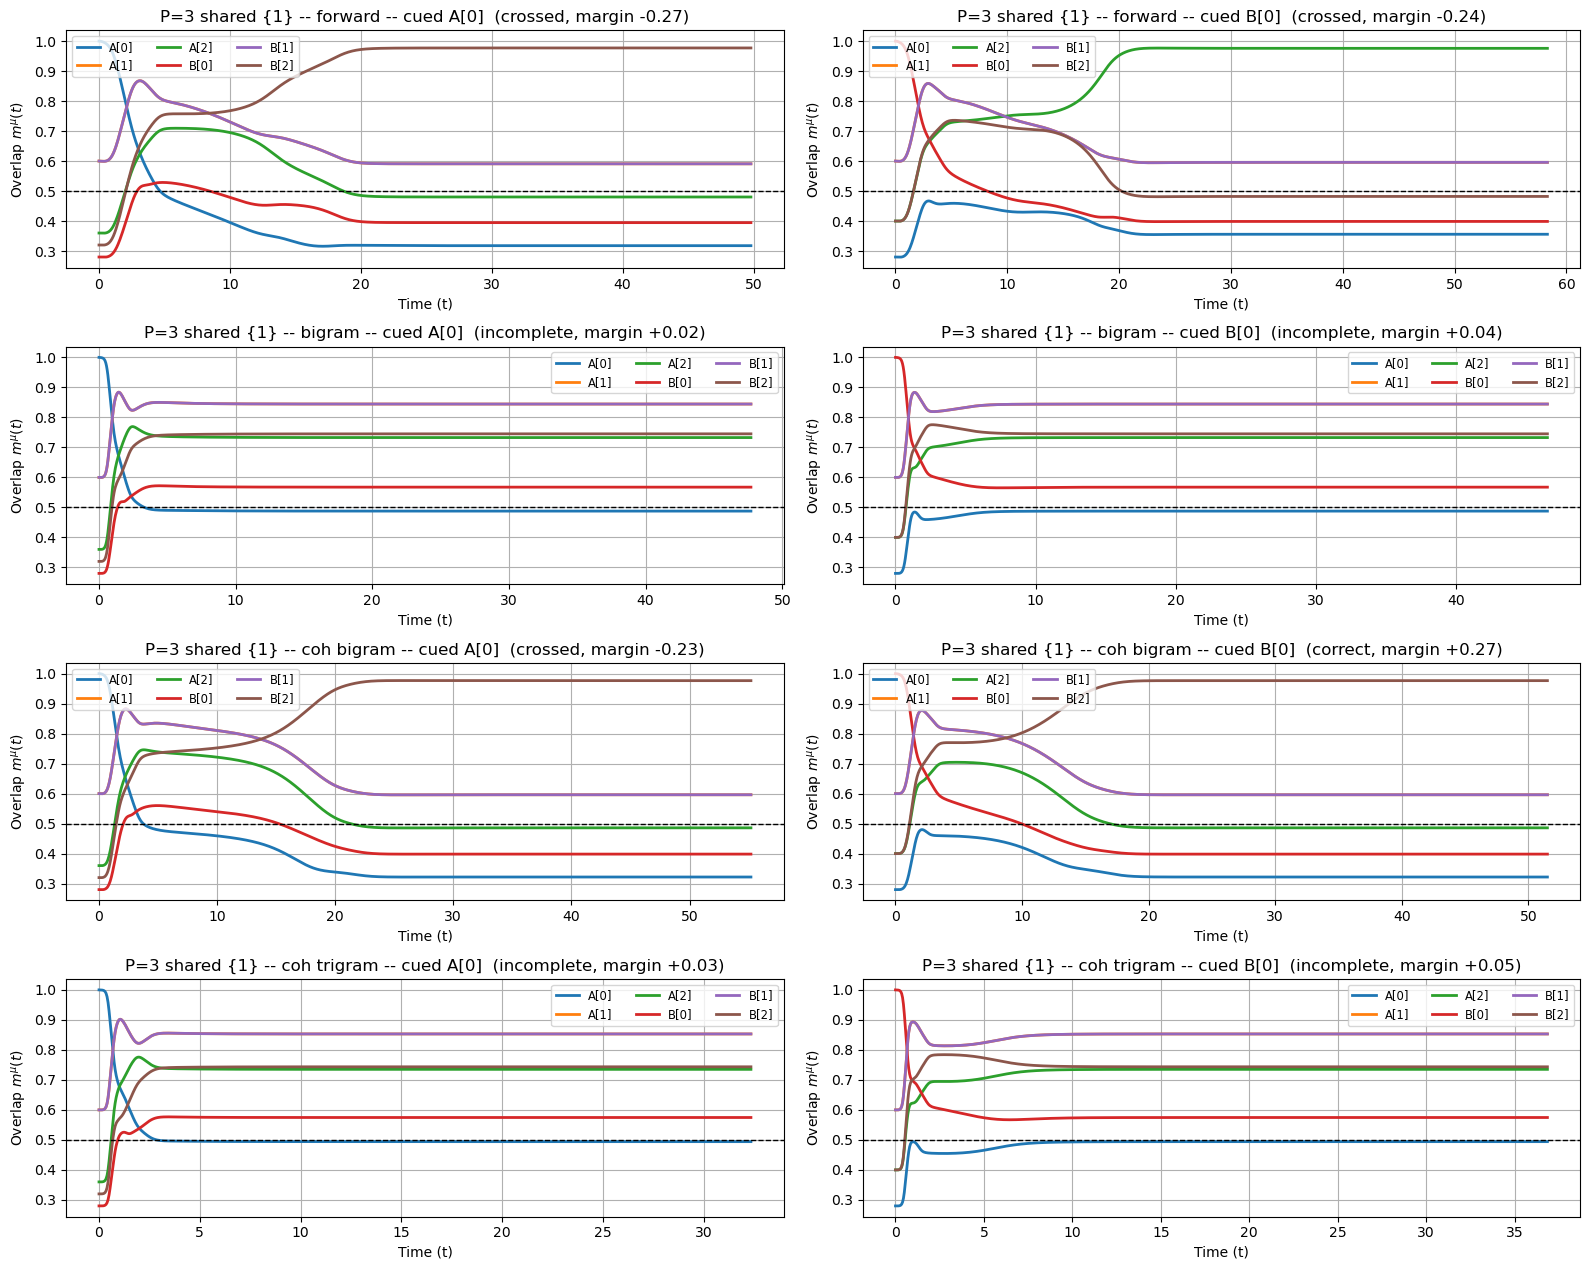

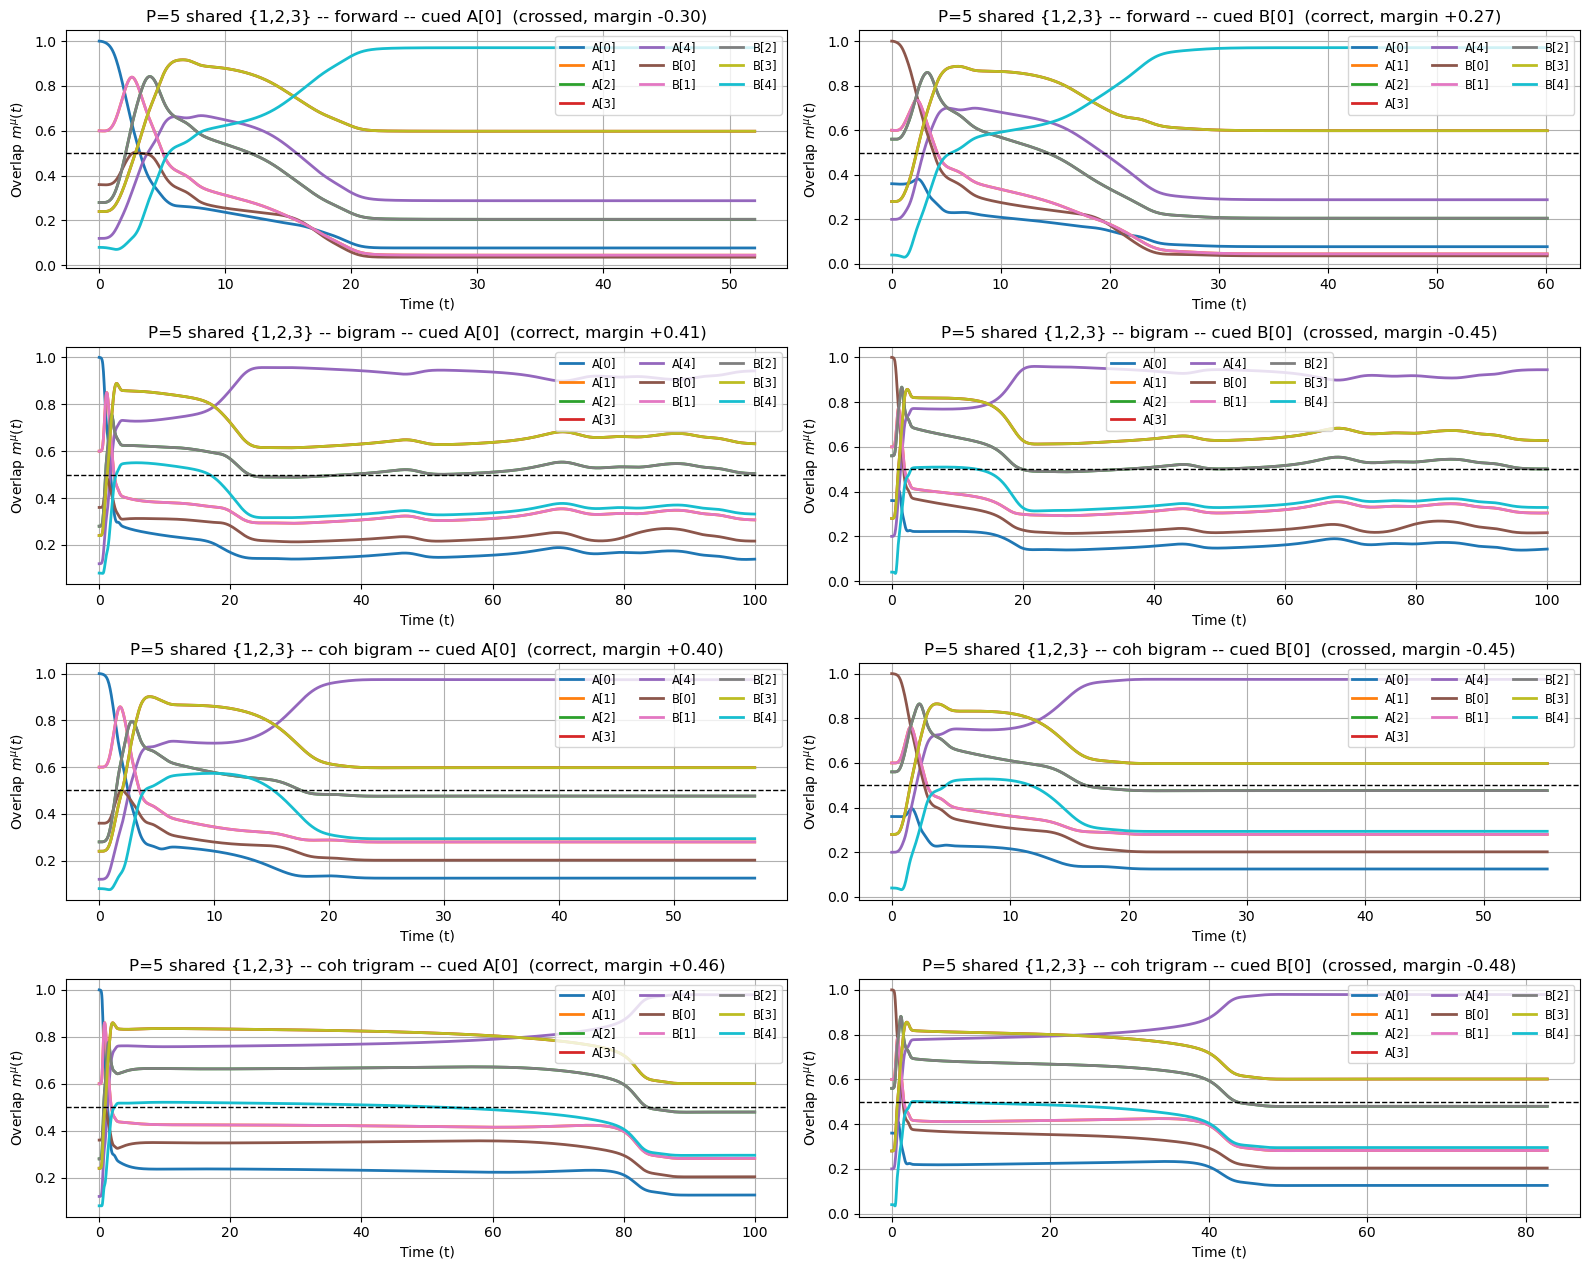

In [14]:
PICKED = ["forward", "bigram", "coh bigram", "coh trigram"]

for first, tag in [(first_e1, "P=3 shared {1}"), (first_e3, "P=5 shared {1,2,3}")]:
    fig, axes = plt.subplots(len(PICKED), 2, figsize=(16, 3.2 * len(PICKED)))
    for row, rule in enumerate(PICKED):
        net, multi, out = first[rule]
        for col, name in enumerate(("A", "B")):
            net.plot(out[name]["result"], multi, ax=axes[row, col],
                     title=f"{tag} -- {rule} -- cued {name}[0]  ({out[name]['outcome']}, "
                           f"margin {out[name]['margin']:+.2f})")
            axes[row, col].axhline(CONFIG["tolerance"], color="k", ls="--", lw=1)
    plt.tight_layout(); plt.show()

# 100 Seed test


In [15]:
CORRUPTION_TARGET = CONFIG["corruption_rate"]   # 0.2
CORRUPTION_SPREAD = 0.08                        # per-seed rate ~ U[0.12, 0.28]
SEED_TRIALS       = 100


def sample_corruption_rate(target, spread, N, rng):
    """One corruption rate, stochastically rounded to a whole flip count.

    Returns (k + 0.5)/N so that corrupt_phase's int() truncation lands on exactly k, where
    k = floor(rN) + Bernoulli(frac(rN)) and so E[k] = rN."""
    rate = rng.uniform(target - spread, target + spread)
    exact = rate * N
    floor = np.floor(exact)
    flips = int(floor + (rng.random() < exact - floor))
    return (flips + 0.5) / N


def seed_sweep(raw_catalogue, seq_len, shared_idx, duration, trials=SEED_TRIALS, seed=0):
    """`rule_sweep` with one corruption rate drawn per trial instead of a fixed one.

    Takes the *raw* catalogue and gain-normalizes per trial at that trial's rate, for the
    reason in the note above. Every rule is re-seeded to the same value, so all of them see
    the identical instances at the identical rates."""
    hi = max(shared_idx)
    stats, rates = {}, []
    for rule, raw in raw_catalogue.items():
        rng = np.random.default_rng(seed)
        counter, wins, margins, rates = Counter(), 0, [], []
        for _ in range(trials):
            rate = sample_corruption_rate(CORRUPTION_TARGET, CORRUPTION_SPREAD, N, rng)
            rates.append(rate)
            net = kc.ContextNetwork(rule=kc.unit_gain(raw, rate), N=N, seed=10, **CONFIG)
            multi = make_crossover_multisequence3(
                N, rate, int(rng.integers(SEED_POOL)),
                rng.choice(SEED_POOL, size=12, replace=False).tolist(), seq_len, shared_idx)
            labels = multi.labels()
            for name in ("A", "B"):
                other = "B" if name == "A" else "A"
                result = net.simulate(multi, cue=multi[name], cue_idx=0, T=duration)
                counter[classify_unshared(net.decode_sequence_online(result, multi, margin=MARGIN),
                                          multi, name, shared_idx)] += 1
                overlaps = net.overlaps(result["theta_history"], multi)
                own   = overlaps[:, labels.index((name,  hi + 1))].max()
                wrong = overlaps[:, labels.index((other, hi + 1))].max()
                wins += own > wrong
                margins.append(own - wrong)
        attempts = sum(counter.values())
        stats[rule] = dict(counter=counter, attempts=attempts,
                           branch_correct=wins / attempts, margin=float(np.mean(margins)))
        print(f"{rule:<15} correct={counter['correct'] / attempts:>5.0%}  "
              f"crossed={counter['crossed'] / attempts:>5.0%}  "
              f"incomplete={counter['incomplete'] / attempts:>5.0%}   "
              f"branch-correct={wins / attempts:>5.0%}  margin={np.mean(margins):>+6.3f}")
    print(f"  mean sampled rate over the {trials} seeds: {np.mean(rates):.4f}  "
          f"(target {CORRUPTION_TARGET}, range "
          f"[{CORRUPTION_TARGET - CORRUPTION_SPREAD:.2f}, {CORRUPTION_TARGET + CORRUPTION_SPREAD:.2f}])")
    return stats

In [16]:
print(f"P = 5, shared {{2}} -- {SEED_TRIALS} seeds")
seed_out_1 = seed_sweep(RAW_CATALOGUE, 5, (2,), duration=100.0)
print()
print(f"P = 5, shared {{1,2,3}} -- {SEED_TRIALS} seeds")
seed_out_3 = seed_sweep(RAW_CATALOGUE, 5, (1, 2, 3), duration=100.0)

P = 5, shared {2} -- 100 seeds
self            correct=   0%  crossed=   0%  incomplete= 100%   branch-correct=  48%  margin=+0.002
forward         correct=  28%  crossed=  42%  incomplete=  30%   branch-correct=  50%  margin=-0.003
skip-two        correct=   4%  crossed=  24%  incomplete=  71%   branch-correct=  74%  margin=+0.076
self+forward    correct=  21%  crossed=  27%  incomplete=  52%   branch-correct=  49%  margin=-0.002
forward+skip2   correct=  38%  crossed=  34%  incomplete=  28%   branch-correct=  66%  margin=+0.049
bigram          correct=  57%  crossed=  15%  incomplete=  28%   branch-correct=  82%  margin=+0.132
multilag        correct=  40%  crossed=  14%  incomplete=  45%   branch-correct=  85%  margin=+0.133
coh bigram      correct=  55%  crossed=  19%  incomplete=  26%   branch-correct=  75%  margin=+0.097
coh trigram     correct=  48%  crossed=  14%  incomplete=  38%   branch-correct=  85%  margin=+0.144
  mean sampled rate over the 100 seeds: 0.2074  (target 0.2,

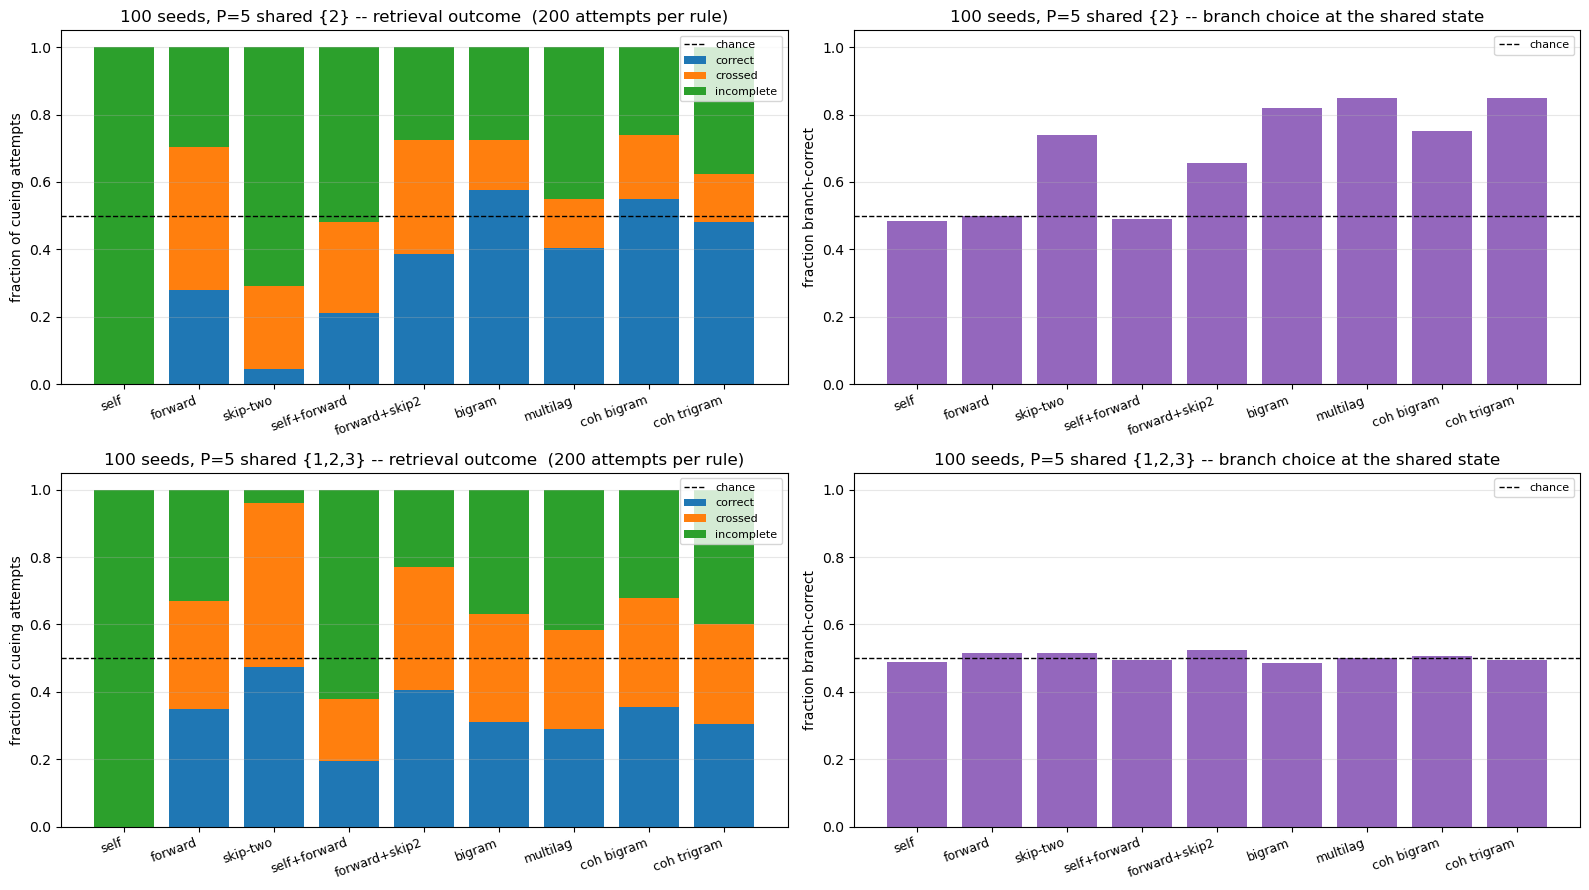

rule                         shared {2}          shared {1,2,3}
                       correct / branch        correct / branch
---------------------------------------------------------------
self                        0% /    48%             0% /    49%
forward                    28% /    50%            35% /    52%
skip-two                    4% /    74%            48% /    52%
self+forward               21% /    49%            20% /    50%
forward+skip2              38% /    66%            40% /    52%
bigram                     57% /    82%            31% /    48%
multilag                   40% /    85%            29% /    50%
coh bigram                 55% /    75%            36% /    50%
coh trigram                48% /    85%            30% /    50%


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
plot_rule_stats(seed_out_1, f"{SEED_TRIALS} seeds, P=5 shared {{2}}", axes=axes[0])
plot_rule_stats(seed_out_3, f"{SEED_TRIALS} seeds, P=5 shared {{1,2,3}}", axes=axes[1])
plt.tight_layout(); plt.show()

print(f"{'rule':<15}{'shared {2}':>24}{'shared {1,2,3}':>24}")
print(f"{'':<15}{'correct / branch':>24}{'correct / branch':>24}")
print("-" * 63)
for rule in seed_out_1:
    s1, s3 = seed_out_1[rule], seed_out_3[rule]
    print(f"{rule:<15}"
          f"{s1['counter']['correct'] / s1['attempts']:>15.0%} /{s1['branch_correct']:>7.0%}"
          f"{s3['counter']['correct'] / s3['attempts']:>15.0%} /{s3['branch_correct']:>7.0%}")

Read this against Part II's tables rather than against `transition_matrix.ipynb`'s: the
absolute numbers move because the difficulty distribution changed, and what is being checked
is whether the **ordering** holds once every rule has to cope with a range of corruption
rates instead of one.

---

# Findings


**2. Gain normalization is not optional, and it is the whole reason a naive port fails.**
A gate reading lag $l$ is multiplied by the residual overlap $(1-2\rho)^l \approx 0.6^l$ at
its own operating point, so an un-normalized coherent trigram runs at $0.22\times$ the
forward rule's drive and scores 100% `incomplete` on both $P=5$ geometries — it never
traverses at all, which says nothing about whether the context it reads is useful.
`kc.unit_gain` removes exactly that handicap. Any comparison made without it is measuring
drive strength, not context.

**6. A shared run of length $L$ needs a gate reaching back $\ge L$ — necessary, not
sufficient.** Below reach $L$ every factor of the gate reads a pattern that is itself shared,
so the rule adds drive but no branch information; that is the same geometric statement as the
transition matrix's $\texttt{nhop} \ge L+1$, moved from the drive to the gate. Above it, the
rules are *still* at chance on the run of three, and the lifetime measurement says why: the
gap between the traversed and untraversed predecessor is $+0.63$ at the cue, $+0.02$ two
patterns later, and never recovers — it is $+0.02$ at the branch point too, against a starting
value thirty times larger. The two candidate predecessors are equidistant
from the shared run, so their static overlaps are identical and the whole signal is that
dynamic residual -- which survives about two steps. Reach is cheap to build; the information
is what runs out, which is the constraint Levy and Wu name in the write-up's context section.



## Where to change things

- **Which rules are compared** — the `CATALOGUE` dict. Add an entry and every cell below
  picks it up. Rules outside the named builders are written with `kc.term(target, lags, w)`.
- **The gain** — `G` / `kc.unit_gain`. Drop it to see finding 2.
- **The geometry** — `seq_len` and `shared_idx` passed to `rule_sweep`. The shared run must
  be contiguous with at least one unshared pattern on each side.
- **The reach** — `REACH`, and the `lag=` argument on `bigram_rule` /
  `coherent_trigram_rule`.
- **The multilag weights** — `GRID_W`.
- **The lifetime measurement** — `GAP_TRIALS`.
- **Sampled corruption** — `CORRUPTION_TARGET`, `CORRUPTION_SPREAD`, `SEED_TRIALS`.
- **Settle vs. loop** — `boundary` on `net.simulate`; the rules are relative, so unlike a
  transition matrix they do not need rebuilding for it.
- **Sharpening / factor count** — `d` in `CONFIG` *and* in the rule builders; they must match.
- **Statistics** — `TRIALS`. Each trial is two integrations.